<a href="https://colab.research.google.com/github/yosetcruz/Servicio-Social/blob/main/Jpsimumu.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, ttest_1samp
import seaborn as sns

file_path = 'Jpsimumu.csv'
df = pd.read_csv(file_path, delimiter=',', header=0, encoding='latin1')

In [ ]:
df_num = df.select_dtypes(include=np.number)

descripcion = df_num.describe()
print(descripcion)

print("\nVarianza de las variables:")
print(df_num.var())


                 Run         Event            E1           px1           py1  \
count   20000.000000  2.000000e+04  20000.000000  20000.000000  20000.000000   
mean   166007.478050  3.095465e+08     16.257363     -0.047719     -0.054748   
std      3835.559826  3.138956e+08     11.798906      7.997127      7.913356   
min    160957.000000  5.610000e+03      2.779600    -99.518100    -95.787200   
25%    163589.000000  6.975541e+07      8.781200     -4.864425     -4.856575   
50%    165617.000000  1.612961e+08     12.760900     -0.080650     -0.059950   
75%    167102.000000  5.131895e+08     19.597800      4.851525      4.819525   
max    173692.000000  1.190235e+09    249.377000     98.995700     58.136900   

                pz1           pt1          eta1          phi1            Q1  \
count  20000.000000  20000.000000  20000.000000  20000.000000  20000.000000   
mean       0.021512      9.381309     -0.000869     -0.011470      0.185300   
std       16.641427      6.412987      1.2

In [ ]:
print(df.columns)

Index(['Run', 'Event', 'type1', 'E1', 'px1', 'py1', 'pz1', 'pt1', 'eta1',
       'phi1', 'Q1', 'type2', 'E2', 'px2', 'py2', 'pz2', 'pt2', 'eta2', 'phi2',
       'Q2'],
      dtype='object')


In [ ]:
# Variables correctas
variables = ['pt1', 'pt2', 'eta1', 'eta2', 'phi1', 'phi2']

# Convertir a numérico y manejar errores
df_plot = df[variables].apply(pd.to_numeric, errors='coerce')


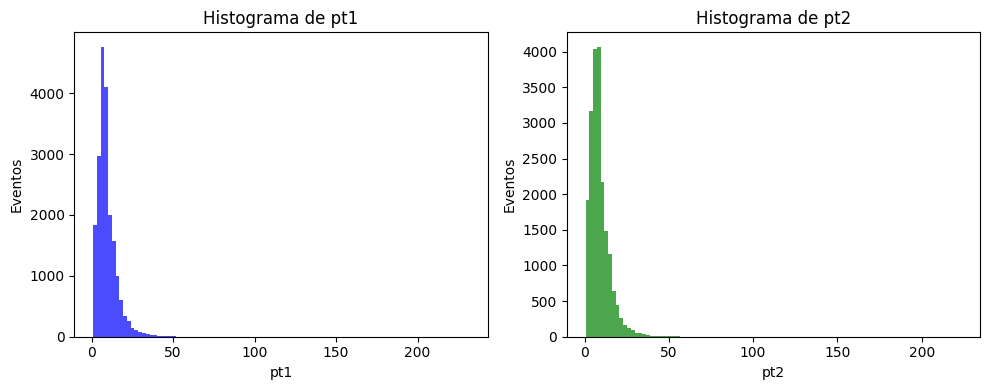

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df_plot['pt1'].dropna(), bins=100, color='blue', alpha=0.7)
plt.xlabel('pt1')
plt.ylabel('Eventos')
plt.title('Histograma de pt1')

plt.subplot(1, 2, 2)
plt.hist(df_plot['pt2'].dropna(), bins=100, color='green', alpha=0.7)
plt.xlabel('pt2')
plt.ylabel('Eventos')
plt.title('Histograma de pt2')

plt.tight_layout()
plt.show()

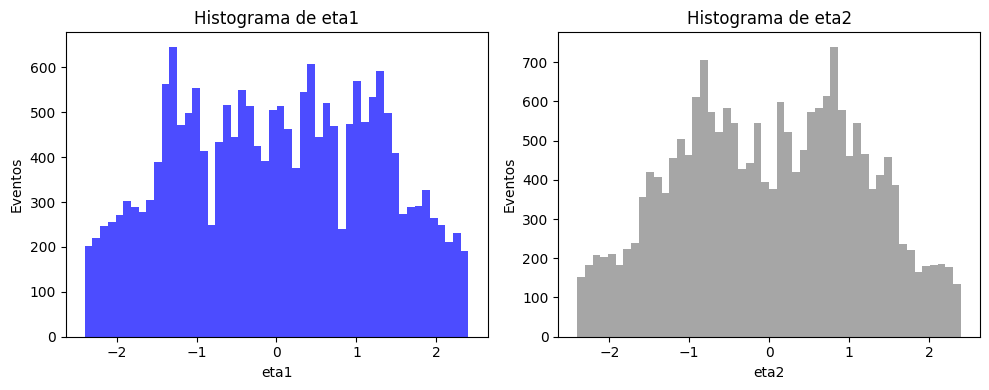

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df_plot['eta1'].dropna(), bins=50, color='blue', alpha=0.7)
plt.xlabel('eta1')
plt.ylabel('Eventos')
plt.title('Histograma de eta1')

plt.subplot(1, 2, 2)
plt.hist(df_plot['eta2'].dropna(), bins=50, color='grey', alpha=0.7)
plt.xlabel('eta2')
plt.ylabel('Eventos')
plt.title('Histograma de eta2')

plt.tight_layout()
plt.show()

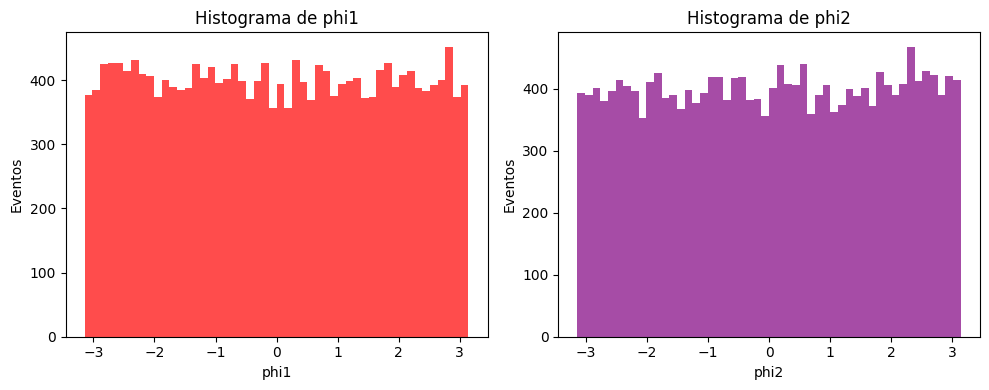

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df_plot['phi1'].dropna(), bins=50, color='red', alpha=0.7)
plt.xlabel('phi1')
plt.ylabel('Eventos')
plt.title('Histograma de phi1')

plt.subplot(1, 2, 2)
plt.hist(df_plot['phi2'].dropna(), bins=50, color='purple', alpha=0.7)
plt.xlabel('phi2')
plt.ylabel('Eventos')
plt.title('Histograma de phi2')

plt.tight_layout()
plt.show()

In [ ]:
print("Resumen pt1:")
print(df_plot['pt1'].describe())

print("\nResumen pt2:")
print(df_plot['pt2'].describe())

print("\nResumen phi1:")
print(df_plot['phi1'].describe())

print("\nResumen phi2:")
print(df_plot['phi2'].describe())

print("\nResumen eta1:")
print(df_plot['eta1'].describe())

print("\nResumen eta2:")
print(df_plot['eta2'].describe())




Resumen pt1:
count    20000.000000
mean         9.381309
std          6.412987
min          0.959800
25%          5.786850
50%          8.085500
75%         11.512750
max        231.431000
Name: pt1, dtype: float64

Resumen pt2:
count    20000.000000
mean         9.073367
std          6.407693
min          0.682800
25%          5.054675
50%          7.780900
75%         11.337675
max        223.435000
Name: pt2, dtype: float64

Resumen phi1:
count    20000.000000
mean        -0.011470
std          1.819284
min         -3.141400
25%         -1.590075
50%         -0.019300
75%          1.573750
max          3.141400
Name: phi1, dtype: float64

Resumen phi2:
count    20000.000000
mean         0.026738
std          1.821130
min         -3.141300
25%         -1.545625
50%          0.045950
75%          1.618550
max          3.141400
Name: phi2, dtype: float64

Resumen eta1:
count    20000.000000
mean        -0.000869
std          1.227777
min         -2.397500
25%         -1.045750
50%     


<center>$Formula$</center>

$$
M^2 = 2\,p_{T1}\,p_{T2}\left[\cosh\left(\eta_1-\eta_2\right)-\cos\left(\phi_1-\phi_2\right)\right]
$$



In [ ]:
df_num['M2'] = 2*df_num['pt1']*df_num['pt2']*(np.cosh(df_num['eta1'] - df_num['eta2']) - np.cos(df_num['phi1'] - df_num['phi2']))

df_num['M'] = np.sqrt(df_num['M2'])


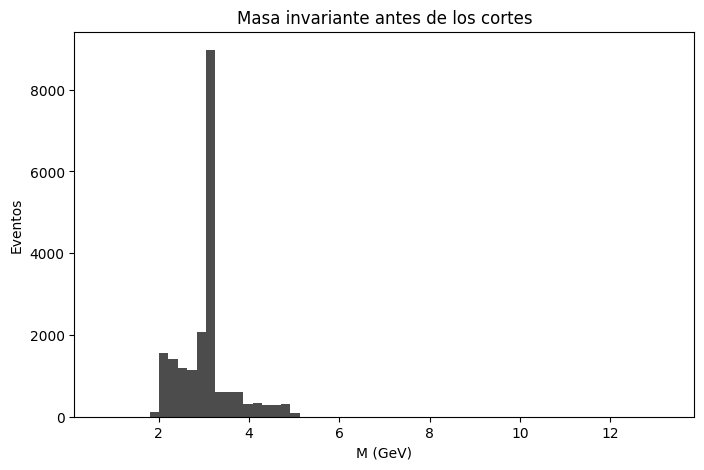

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df_num['M'].dropna(), bins=60, color='black', alpha=0.7)
plt.xlabel('M (GeV)')
plt.ylabel('Eventos')
plt.title('Masa invariante antes de los cortes')
plt.show()


In [ ]:
cut_pt = df[(df['pt1'] > 20) &
    (df['pt2'] > 20)]


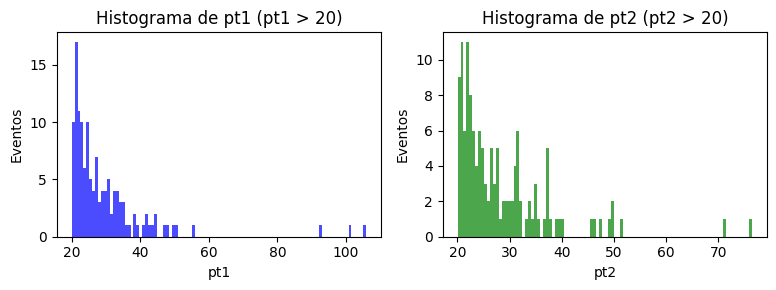

In [ ]:
plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.hist(cut_pt['pt1'].dropna(), bins=100, color='blue', alpha=0.7)
plt.xlabel('pt1')
plt.ylabel('Eventos')
plt.title('Histograma de pt1 (pt1 > 20)')

plt.subplot(1, 2, 2)
plt.hist(cut_pt['pt2'].dropna(), bins=100, color='green', alpha=0.7)
plt.xlabel('pt2')
plt.ylabel('Eventos')
plt.title('Histograma de pt2 (pt2 > 20)')

plt.tight_layout()
plt.show()


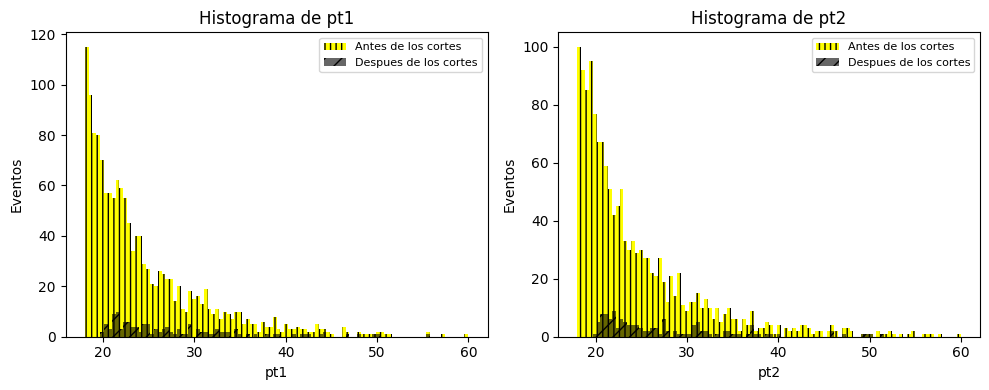

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title('Histograma de pt1')
rango_pt1 = (18, 60)
plt.hist(df_plot['pt1'].dropna(), bins=100,color='yellow', hatch = '|||', range = rango_pt1, label= 'Antes de los cortes')
plt.hist(cut_pt['pt1'].dropna(), bins=100, color='black',hatch = '//',  alpha=(0.6), range=rango_pt1, label= 'Despues de los cortes')
plt.xlabel('pt1')
plt.ylabel('Eventos')
plt.legend(fontsize=8)

plt.subplot(1, 2, 2)
plt.title('Histograma de pt2')
rango_pt2 = (18, 60)
plt.hist(df_plot['pt2'].dropna(), bins=100,color='yellow', hatch = '|||',range=rango_pt2, label= 'Antes de los cortes')
plt.hist(cut_pt['pt2'].dropna(), bins=100, color='black',hatch = '//',  alpha=(0.6), range=rango_pt2, label= 'Despues de los cortes')
plt.xlabel('pt2')
plt.ylabel('Eventos')
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
cut_eta1 = df[np.abs(df['eta1']) < 2.1]
cut_eta2 = df[np.abs(df['eta2']) < 2.1]

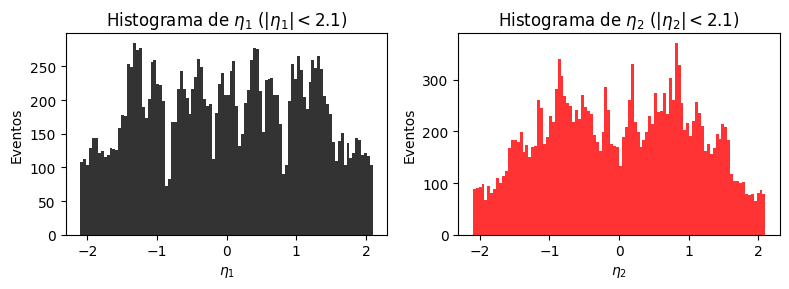

In [ ]:

plt.figure(figsize=(8, 3))

plt.subplot(1, 2, 1)
plt.hist(cut_eta1['eta1'].dropna(), bins=100, color='black', alpha=0.8)
plt.xlabel(r'$\eta_1$')
plt.ylabel('Eventos')
plt.title(r'Histograma de $\eta_1$ ($|\eta_1| < 2.1$)')

plt.subplot(1, 2, 2)
plt.hist(cut_eta2['eta2'].dropna(), bins=100, color='red', alpha=0.8)
plt.xlabel(r'$\eta_2$')
plt.ylabel('Eventos')
plt.title(r'Histograma de $\eta_2$ ($|\eta_2| < 2.1$)')

plt.tight_layout()
plt.show()


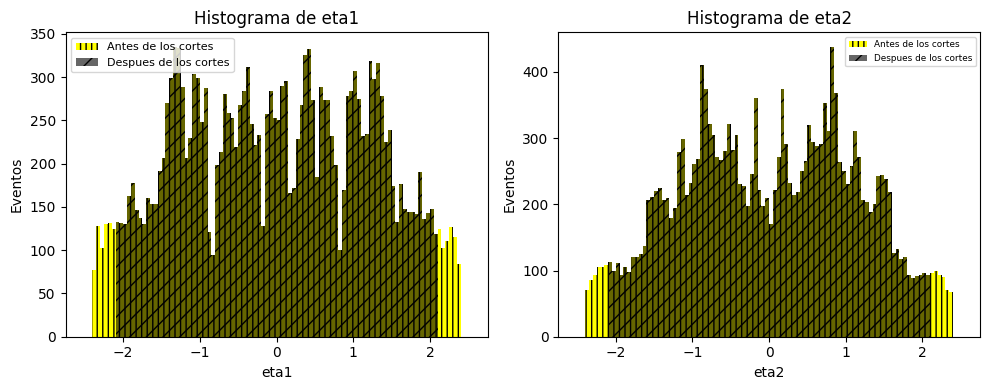

In [ ]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.title('Histograma de eta1')
rango_eta1=(-2.5,2.5)
plt.hist(df_plot['eta1'].dropna(), bins=100,color='yellow', hatch = '|||', range = rango_eta1, label= 'Antes de los cortes')
plt.hist(cut_eta1['eta1'].dropna(), bins=100, color='black',hatch = '//',  alpha=(0.6), range=rango_eta1, label= 'Despues de los cortes')
plt.xlabel('eta1')
plt.ylabel('Eventos')
plt.legend(fontsize=8)



plt.subplot(1, 2, 2)
plt.title('Histograma de eta2')
rango_eta2=(-2.5,2.5)
plt.hist(df_plot['eta2'].dropna(), bins=100,color='yellow', hatch = '|||', range = rango_eta2, label= 'Antes de los cortes')
plt.hist(cut_eta2['eta2'].dropna(), bins=100, color='black',hatch = '//',  alpha=(0.6), range=rango_eta2, label= 'Despues de los cortes')
plt.xlabel('eta2')
plt.ylabel('Eventos')
plt.legend(fontsize=6.4)


plt.tight_layout()
plt.show()

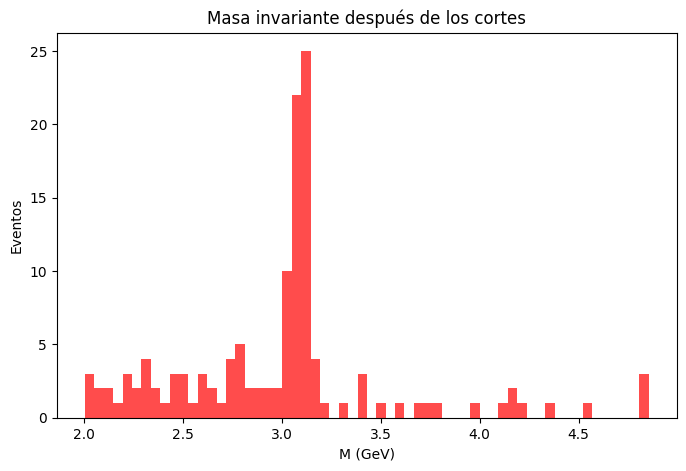

In [ ]:
# Filtrar df_num por los cortes de eta y pt
cut_eta = df_num[
    (np.abs(df_num['eta1']) < 2.1) &
    (np.abs(df_num['eta2']) < 2.1) &
    (df_num['pt1'] > 20) &
    (df_num['pt2'] > 20)]

plt.figure(figsize=(8,5))
plt.hist(cut_eta['M'].dropna(), bins=60, color='red', alpha=0.7)
plt.xlabel('M (GeV)')
plt.ylabel('Eventos')
plt.title('Masa invariante después de los cortes')
plt.show()


In [ ]:
flow = {
    'Sin cortes': len(df_num),
    'pT > 20': len(cut_pt),
    '|eta| < 2.1': len(cut_eta)}

cutflow = pd.DataFrame.from_dict(flow, orient='index', columns=['Eventos'])
print(cutflow)


             Eventos
Sin cortes     20000
pT > 20          132
|eta| < 2.1      131


In [ ]:
cutflow['Eficiencia (%)'] = 100 * cutflow['Eventos'] / cutflow.iloc[0,0]
print(cutflow)


             Eventos  Eficiencia (%)
Sin cortes     20000         100.000
pT > 20          132           0.660
|eta| < 2.1      131           0.655


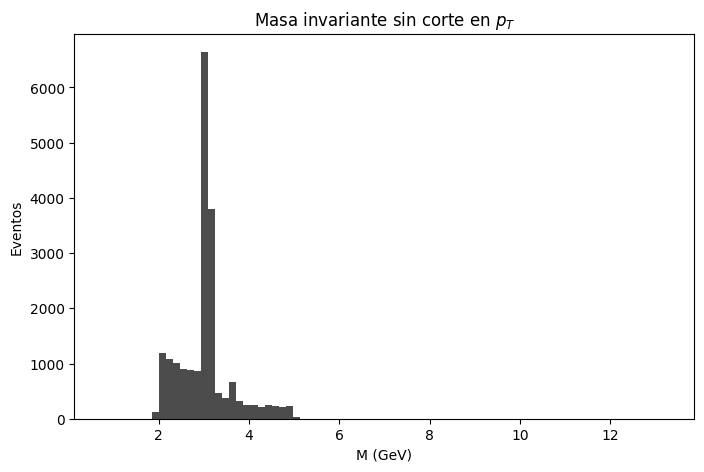

In [ ]:
# Masa invariante sin cortes en pT
df_num['M2'] = 2 * df_num['pt1'] * df_num['pt2'] * (np.cosh(df_num['eta1'] - df_num['eta2']) - np.cos(df_num['phi1'] - df_num['phi2']))
df_num['M'] = np.sqrt(df_num['M2'])

plt.figure(figsize=(8,5))
plt.hist(df_num['M'].dropna(), bins=80, color='black', alpha=0.7)
plt.xlabel('M (GeV)')
plt.ylabel('Eventos')
plt.title('Masa invariante sin corte en $p_T$')
plt.show()


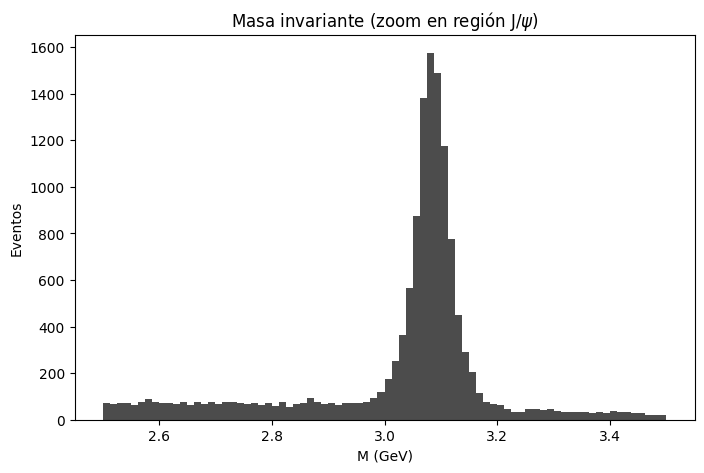

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df_num['M'].dropna(), bins=80, range=(2.5, 3.5), color='black', alpha=0.7)
plt.xlabel('M (GeV)')
plt.ylabel('Eventos')
plt.title(r'Masa invariante (zoom en región J/$\psi$)')
plt.show()


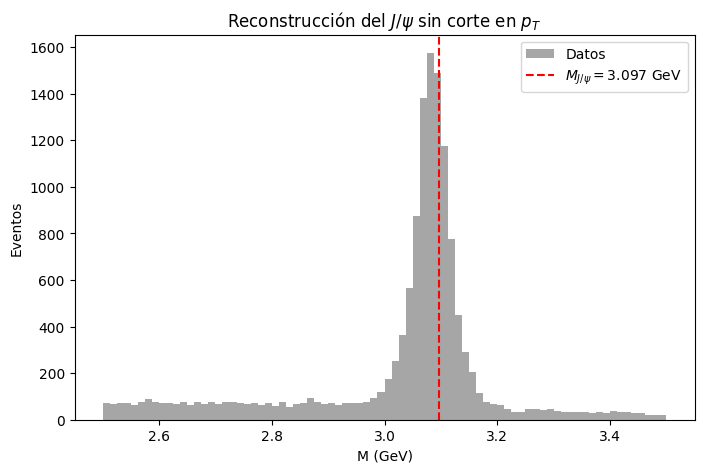

In [ ]:
plt.figure(figsize=(8,5))
plt.hist(df_num['M'].dropna(), bins=80, range=(2.5, 3.5), color='gray', alpha=0.7, label='Datos')
plt.axvline(3.097, color='red', linestyle='--', label=r'$M_{J/\psi} = 3.097$ GeV')
plt.xlabel('M (GeV)')
plt.ylabel('Eventos')
plt.title(r'Reconstrucción del $J/\psi$ sin corte en $p_T$')
plt.legend()
plt.show()


In [ ]:
tabla_masa = df_num[['M']].describe()
print(tabla_masa)


                  M
count  20000.000000
mean       3.044139
std        0.590053
min        0.755175
25%        2.749402
50%        3.074201
75%        3.122578
max       13.239391
